<a href="https://colab.research.google.com/github/asheldrick-research/ecsm-framework/blob/main/ECSM_Electron_Like_Packet_Transition_Rules_Spectral_Gaps_V14.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECSM Electron-Like Packet Transition Rules and Spectral Gaps — V14

V14 starts from the V12/V13 response-well bound shell hierarchy and tests whether structured transition rules and spectral-gap multiplets appear. This is a bridge test, not a full atomic spectroscopy claim.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, json, zipfile
from pathlib import Path
OUT=Path('ecsm_electron_like_transition_rules_spectral_gaps_v14_out'); OUT.mkdir(exist_ok=True)
def savefig(name):
    path=OUT/name; plt.tight_layout(); plt.savefig(path,dpi=180); plt.show(); return path
def write_json(obj,name):
    path=OUT/name
    with open(path,'w') as f: json.dump(obj,f,indent=2)
    return path
print('Output directory:', OUT)

Output directory: ecsm_electron_like_transition_rules_spectral_gaps_v14_out


In [2]:
# CELL 2 — inherited packet and alpha/beta closure
packet_summary={
 'N_plus':0.0009716378827065886,'N_zero':1.000146008084612,'N_minus':2.998882354032682,
 'q_eff':-0.9993035720499918,'R_rms':5.236462555204353,'count_total':4.0,
 'source':'V13 fixed V3b/V4b/V5/V6b/V7/V8c/V9/V10/V11/V12 electron-like packet'}
write_json(packet_summary,'fixed_packet_summary_v14.json')
print(json.dumps(packet_summary,indent=2))
s1=np.array([[0,1],[1,0]],complex); s2=np.array([[0,-1j],[1j,0]],complex); s3=np.array([[1,0],[0,-1]],complex)
I2=np.eye(2,dtype=complex); Z2=np.zeros((2,2),complex)
def block(a,b,c,d): return np.block([[a,b],[c,d]])
alpha=[block(Z2,s1,s1,Z2),block(Z2,s2,s2,Z2),block(Z2,s3,s3,Z2)]
beta=block(I2,Z2,Z2,-I2); I4=np.eye(4,dtype=complex)
tests=[]
for i,a in enumerate(alpha):
    tests.append((f'alpha_{i+1}^2=I',np.max(np.abs(a@a-I4))))
    tests.append((f'{{alpha_{i+1},beta}}=0',np.max(np.abs(a@beta+beta@a))))
for i in range(3):
    for j in range(i+1,3): tests.append((f'{{alpha_{i+1},alpha_{j+1}}}=0',np.max(np.abs(alpha[i]@alpha[j]+alpha[j]@alpha[i]))))
tests.append(('beta^2=I',np.max(np.abs(beta@beta-I4))))
alpha_df=pd.DataFrame(tests,columns=['test','error']); alpha_df.to_csv(OUT/'alpha_beta_algebra_tests_v14.csv',index=False)
print('Max alpha/beta error:',float(alpha_df.error.max())); display(alpha_df)

{
  "N_plus": 0.0009716378827065886,
  "N_zero": 1.000146008084612,
  "N_minus": 2.998882354032682,
  "q_eff": -0.9993035720499918,
  "R_rms": 5.236462555204353,
  "count_total": 4.0,
  "source": "V13 fixed V3b/V4b/V5/V6b/V7/V8c/V9/V10/V11/V12 electron-like packet"
}
Max alpha/beta error: 0.0


,test,error
0,alpha_1^2=I,0.0
1,"{alpha_1,beta}=0",0.0
2,alpha_2^2=I,0.0
3,"{alpha_2,beta}=0",0.0
4,alpha_3^2=I,0.0
5,"{alpha_3,beta}=0",0.0
6,"{alpha_1,alpha_2}=0",0.0
7,"{alpha_1,alpha_3}=0",0.0
8,"{alpha_2,alpha_3}=0",0.0
9,beta^2=I,0.0


,l,E_iso,r_mean,r_width,capacity,closure
0,0,-1.425486,2.457830,1.047361,2,2
1,1,-1.215405,3.317319,1.089339,6,8
2,2,-1.010407,4.031522,1.119857,10,18
3,3,-0.810570,4.668400,1.147700,14,32


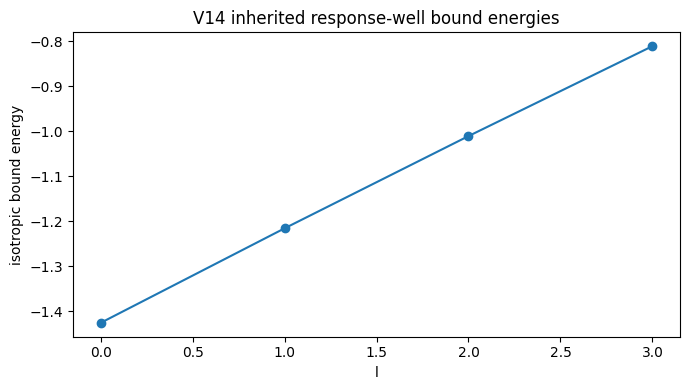

PosixPath('ecsm_electron_like_transition_rules_spectral_gaps_v14_out/fig_v14_inherited_bound_energy_ladder.png')

In [3]:
# CELL 3 — inherited V12/V13 response-well energies
base_radial=pd.DataFrame({'l':[0,1,2,3],'E_iso':[-1.425485922,-1.215404863,-1.010406689,-0.810569813],
'r_mean':[2.457830,3.317319,4.031522,4.668400],'r_width':[1.047361,1.089339,1.119857,1.147700]})
base_radial['capacity']=2*(2*base_radial.l+1)
base_radial['closure']=[int(np.sum(2*(2*np.arange(0,l+1)+1))) for l in base_radial.l]
base_radial.to_csv(OUT/'response_well_radial_summary_v14.csv',index=False)
display(base_radial)
plt.figure(figsize=(7,4)); plt.plot(base_radial.l,base_radial.E_iso,marker='o'); plt.xlabel('l'); plt.ylabel('isotropic bound energy'); plt.title('V14 inherited response-well bound energies'); savefig('fig_v14_inherited_bound_energy_ladder.png')

Isotropic modes: 32 Anisotropic modes: 32


,mode_id,l,m,internal_state,chi,epsilon,energy,parent_energy,split_shift,r_mean,r_width,shell_capacity
0,0,0,0,0,1.0,0.01,-1.425486,-1.425486,0.000000,2.457830,1.047361,2
1,1,0,0,1,1.0,0.01,-1.425486,-1.425486,0.000000,2.457830,1.047361,2
2,2,1,-1,0,1.0,0.01,-1.212072,-1.215405,0.003333,3.317319,1.089339,6
3,3,1,-1,1,1.0,0.01,-1.212072,-1.215405,0.003333,3.317319,1.089339,6
4,4,1,0,0,1.0,0.01,-1.222072,-1.215405,-0.006667,3.317319,1.089339,6
5,5,1,0,1,1.0,0.01,-1.222072,-1.215405,-0.006667,3.317319,1.089339,6
6,6,1,1,0,1.0,0.01,-1.212072,-1.215405,0.003333,3.317319,1.089339,6
7,7,1,1,1,1.0,0.01,-1.212072,-1.215405,0.003333,3.317319,1.089339,6
8,8,2,-2,0,1.0,0.01,-0.990407,-1.010407,0.020000,4.031522,1.119857,10
9,9,2,-2,1,1.0,0.01,-0.990407,-1.010407,0.020000,4.031522,1.119857,10


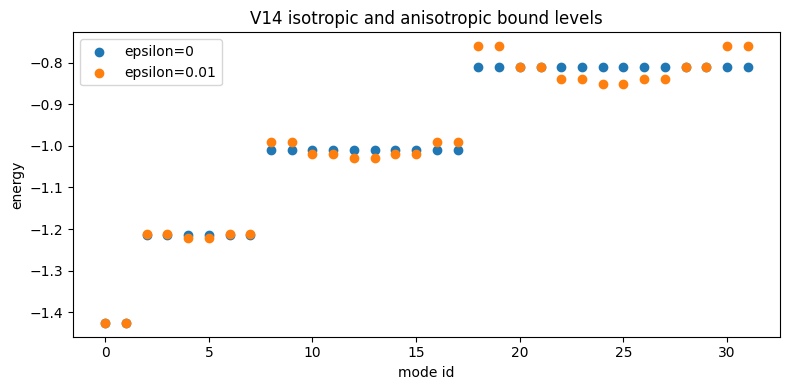

PosixPath('ecsm_electron_like_transition_rules_spectral_gaps_v14_out/fig_v14_bound_modes_isotropic_vs_anisotropic.png')

In [4]:
# CELL 4 — generate isotropic and anisotropic modes
def split_pattern(l,m):
    if l==0: return 0.0
    return float(m*m - l*(l+1)/3.0)
def build_modes(epsilon=0.0, chi=1.0):
    rows=[]; mode_id=0; E0=float(base_radial.loc[base_radial.l==0,'E_iso'].iloc[0]); scale=np.sqrt(chi)
    for _,r in base_radial.iterrows():
        l=int(r.l); E_chi=E0+scale*(float(r.E_iso)-E0)
        for m in range(-l,l+1):
            for s in [0,1]:
                E=E_chi+epsilon*split_pattern(l,m)
                rows.append({'mode_id':mode_id,'l':l,'m':m,'internal_state':s,'chi':chi,'epsilon':epsilon,'energy':E,'parent_energy':E_chi,'split_shift':E-E_chi,'r_mean':float(r.r_mean),'r_width':float(r.r_width),'shell_capacity':2*(2*l+1)})
                mode_id+=1
    return pd.DataFrame(rows)
modes_iso=build_modes(0.0,1.0); modes_aniso=build_modes(0.01,1.0)
modes_iso.to_csv(OUT/'isotropic_bound_modes_v14.csv',index=False); modes_aniso.to_csv(OUT/'anisotropic_bound_modes_v14.csv',index=False)
print('Isotropic modes:',len(modes_iso),'Anisotropic modes:',len(modes_aniso)); display(modes_aniso.head(14))
plt.figure(figsize=(8,4)); plt.scatter(modes_iso.mode_id,modes_iso.energy,label='epsilon=0'); plt.scatter(modes_aniso.mode_id,modes_aniso.energy,label='epsilon=0.01'); plt.xlabel('mode id'); plt.ylabel('energy'); plt.title('V14 isotropic and anisotropic bound levels'); plt.legend(); savefig('fig_v14_bound_modes_isotropic_vs_anisotropic.png')

In [5]:
# CELL 5 — selection rules and transition table
def radial_overlap_proxy(li,lf):
    ri=float(base_radial.loc[base_radial.l==li,'r_mean'].iloc[0]); rf=float(base_radial.loc[base_radial.l==lf,'r_mean'].iloc[0])
    wi=float(base_radial.loc[base_radial.l==li,'r_width'].iloc[0]); wf=float(base_radial.loc[base_radial.l==lf,'r_width'].iloc[0])
    return float(np.exp(-((ri-rf)**2)/(2*(wi*wi+wf*wf))))
def selection_strength(mi,mf,li,lf):
    dm=mf-mi
    if abs(lf-li)!=1 or abs(dm)>1: return 0.0
    return radial_overlap_proxy(li,lf)*(1.0 if dm==0 else 0.65)
def build_transitions(modes):
    rows=[]
    for _,a in modes.iterrows():
        for _,b in modes.iterrows():
            if float(b.energy)<=float(a.energy): continue
            li,lf=int(a.l),int(b.l); mi,mf=int(a.m),int(b.m); si,sf=int(a.internal_state),int(b.internal_state)
            allowed=(abs(lf-li)==1) and (abs(mf-mi)<=1) and (si==sf)
            rows.append({'initial_mode':int(a.mode_id),'final_mode':int(b.mode_id),'l_i':li,'m_i':mi,'s_i':si,'l_f':lf,'m_f':mf,'s_f':sf,'delta_l':lf-li,'delta_m':mf-mi,'same_internal':si==sf,'E_i':float(a.energy),'E_f':float(b.energy),'delta_E':float(b.energy-a.energy),'allowed':bool(allowed),'strength_proxy':float(selection_strength(mi,mf,li,lf) if allowed else 0.0),'transition_family':f'l{li}->l{lf}'})
    return pd.DataFrame(rows)
trans_iso=build_transitions(modes_iso); trans_aniso=build_transitions(modes_aniso)
trans_iso.to_csv(OUT/'isotropic_transition_table_v14.csv',index=False); trans_aniso.to_csv(OUT/'anisotropic_transition_table_v14.csv',index=False)
allowed_iso=trans_iso[trans_iso.allowed].copy(); allowed_aniso=trans_aniso[trans_aniso.allowed].copy()
print('Allowed isotropic:',len(allowed_iso),'Allowed anisotropic:',len(allowed_aniso)); display(allowed_aniso.head(20))

Allowed isotropic: 54 Allowed anisotropic: 54


,initial_mode,final_mode,l_i,m_i,s_i,l_f,m_f,s_f,delta_l,delta_m,same_internal,E_i,E_f,delta_E,allowed,strength_proxy,transition_family
0,0,2,0,0,0,1,-1,0,1,-1,True,-1.425486,-1.212072,0.213414,True,0.552929,l0->l1
2,0,4,0,0,0,1,0,0,1,0,True,-1.425486,-1.222072,0.203414,True,0.850660,l0->l1
4,0,6,0,0,0,1,1,0,1,1,True,-1.425486,-1.212072,0.213414,True,0.552929,l0->l1
31,1,3,0,0,1,1,-1,1,1,-1,True,-1.425486,-1.212072,0.213414,True,0.552929,l0->l1
33,1,5,0,0,1,1,0,1,1,0,True,-1.425486,-1.222072,0.203414,True,0.850660,l0->l1
35,1,7,0,0,1,1,1,1,1,1,True,-1.425486,-1.212072,0.213414,True,0.552929,l0->l1
60,2,8,1,-1,0,2,-2,0,1,-1,True,-1.212072,-0.990407,0.221665,True,0.585507,l1->l2
62,2,10,1,-1,0,2,-1,0,1,0,True,-1.212072,-1.020407,0.191665,True,0.900780,l1->l2
64,2,12,1,-1,0,2,0,0,1,1,True,-1.212072,-1.030407,0.181665,True,0.585507,l1->l2
85,3,9,1,-1,1,2,-2,1,1,-1,True,-1.212072,-0.990407,0.221665,True,0.585507,l1->l2


,transition_family,n_allowed,gap_mean,gap_min,gap_max,gap_width,strength_sum_proxy
0,l0->l1,6,0.210081,0.210081,0.210081,0.0,3.913034
1,l1->l2,18,0.204998,0.204998,0.204998,0.0,12.430765
2,l2->l3,30,0.199837,0.199837,0.199837,0.0,21.255609


,transition_family,n_allowed,gap_mean,gap_min,gap_max,gap_width,strength_sum_proxy
0,l0->l1,6,0.210081,0.203414,0.213414,0.01,3.913034
1,l1->l2,18,0.198332,0.181665,0.221665,0.04,12.430765
2,l2->l3,30,0.186504,0.149837,0.229837,0.08,21.255609


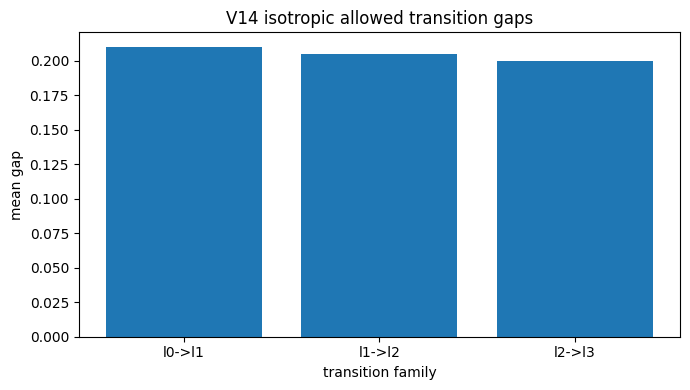

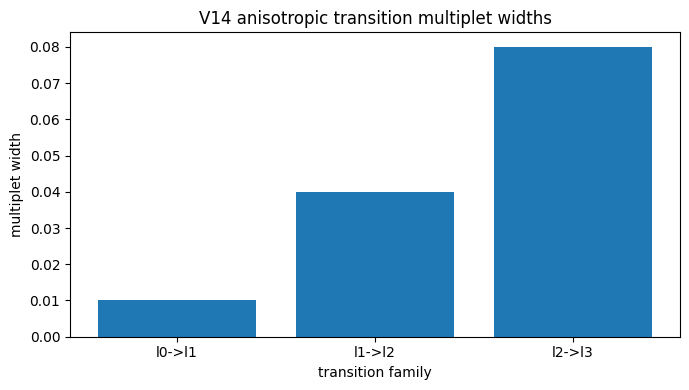

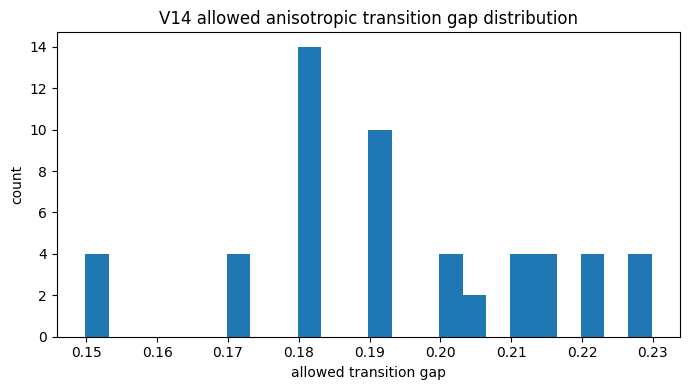

PosixPath('ecsm_electron_like_transition_rules_spectral_gaps_v14_out/fig_v14_anisotropic_transition_gap_distribution.png')

In [6]:
# CELL 6 — transition-family summaries
def transition_family_summary(trans):
    al=trans[trans.allowed].copy(); rows=[]
    for fam,g in al.groupby('transition_family'):
        rows.append({'transition_family':fam,'n_allowed':len(g),'gap_mean':float(g.delta_E.mean()),'gap_min':float(g.delta_E.min()),'gap_max':float(g.delta_E.max()),'gap_width':float(g.delta_E.max()-g.delta_E.min()),'strength_sum_proxy':float(g.strength_proxy.sum())})
    return pd.DataFrame(rows).sort_values('transition_family').reset_index(drop=True)
iso_fam=transition_family_summary(trans_iso); aniso_fam=transition_family_summary(trans_aniso)
iso_fam.to_csv(OUT/'isotropic_transition_family_summary_v14.csv',index=False); aniso_fam.to_csv(OUT/'anisotropic_transition_family_summary_v14.csv',index=False)
display(iso_fam); display(aniso_fam)
plt.figure(figsize=(7,4)); plt.bar(iso_fam.transition_family,iso_fam.gap_mean); plt.xlabel('transition family'); plt.ylabel('mean gap'); plt.title('V14 isotropic allowed transition gaps'); savefig('fig_v14_isotropic_transition_gaps.png')
plt.figure(figsize=(7,4)); plt.bar(aniso_fam.transition_family,aniso_fam.gap_width); plt.xlabel('transition family'); plt.ylabel('multiplet width'); plt.title('V14 anisotropic transition multiplet widths'); savefig('fig_v14_anisotropic_transition_multiplet_widths.png')
plt.figure(figsize=(7,4)); plt.hist(allowed_aniso.delta_E,bins=24); plt.xlabel('allowed transition gap'); plt.ylabel('count'); plt.title('V14 allowed anisotropic transition gap distribution'); savefig('fig_v14_anisotropic_transition_gap_distribution.png')

,epsilon,n_allowed,max_transition_multiplet_width,mean_transition_multiplet_width,n_transition_families
0,0.0000,54,0.000,0.000000,3
1,0.0010,54,0.008,0.004333,3
2,0.0025,54,0.020,0.010833,3
3,0.0050,54,0.040,0.021667,3
4,0.0100,54,0.080,0.043333,3
5,0.0200,54,0.160,0.086667,3


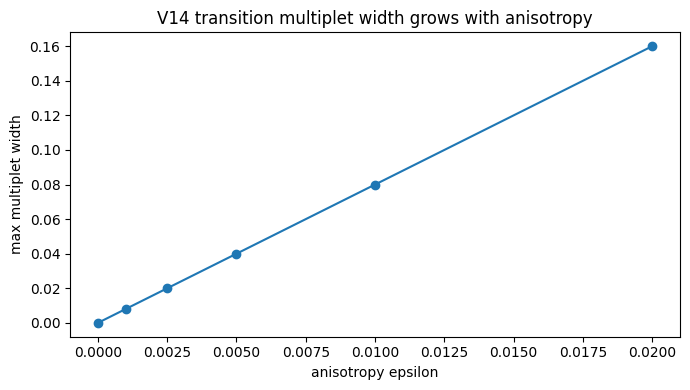

PosixPath('ecsm_electron_like_transition_rules_spectral_gaps_v14_out/fig_v14_transition_multiplet_width_vs_anisotropy.png')

In [7]:
# CELL 7 — anisotropy scan
eps_values=[0.0,0.001,0.0025,0.005,0.01,0.02]; rows=[]
for eps in eps_values:
    tr=build_transitions(build_modes(eps,1.0)); fam=transition_family_summary(tr)
    rows.append({'epsilon':eps,'n_allowed':int(tr.allowed.sum()),'max_transition_multiplet_width':float(fam.gap_width.max()),'mean_transition_multiplet_width':float(fam.gap_width.mean()),'n_transition_families':len(fam)})
eps_scan=pd.DataFrame(rows); eps_scan.to_csv(OUT/'transition_multiplet_anisotropy_scan_v14.csv',index=False); display(eps_scan)
plt.figure(figsize=(7,4)); plt.plot(eps_scan.epsilon,eps_scan.max_transition_multiplet_width,marker='o'); plt.xlabel('anisotropy epsilon'); plt.ylabel('max multiplet width'); plt.title('V14 transition multiplet width grows with anisotropy'); savefig('fig_v14_transition_multiplet_width_vs_anisotropy.png')

,chi,sqrt_chi,n_modes,n_allowed,n_transition_families,mean_allowed_gap,min_allowed_gap,max_allowed_gap,max_multiplet_width,family_list
0,1.00,1.000000,32,54,3,0.193066,0.149837,0.229837,0.08,"l0->l1,l1->l2,l2->l3"
1,0.95,0.974679,32,54,3,0.187934,0.144777,0.224777,0.08,"l0->l1,l1->l2,l2->l3"
2,0.80,0.894427,32,54,3,0.171667,0.128740,0.208740,0.08,"l0->l1,l1->l2,l2->l3"
3,0.50,0.707107,32,54,3,0.133698,0.091306,0.171306,0.08,"l0->l1,l1->l2,l2->l3"
4,0.20,0.447214,32,54,3,0.081019,0.039370,0.119370,0.08,"l0->l1,l1->l2,l2->l3"


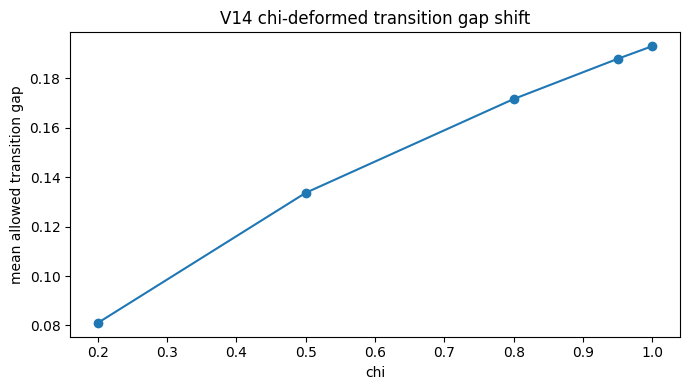

PosixPath('ecsm_electron_like_transition_rules_spectral_gaps_v14_out/fig_v14_chi_transition_gap_shift.png')

In [8]:
# CELL 8 — chi-deformed transition gaps
chi_values=[1.0,0.95,0.8,0.5,0.2]; rows=[]
for chi in chi_values:
    tr=build_transitions(build_modes(0.01,chi)); fam=transition_family_summary(tr); al=tr[tr.allowed]
    rows.append({'chi':chi,'sqrt_chi':float(np.sqrt(chi)),'n_modes':32,'n_allowed':int(tr.allowed.sum()),'n_transition_families':len(fam),'mean_allowed_gap':float(al.delta_E.mean()),'min_allowed_gap':float(al.delta_E.min()),'max_allowed_gap':float(al.delta_E.max()),'max_multiplet_width':float(fam.gap_width.max()),'family_list':','.join(fam.transition_family.tolist())})
chi_df=pd.DataFrame(rows); chi_df.to_csv(OUT/'chi_deformed_transition_gap_scan_v14.csv',index=False); display(chi_df)
plt.figure(figsize=(7,4)); plt.plot(chi_df.chi,chi_df.mean_allowed_gap,marker='o'); plt.xlabel('chi'); plt.ylabel('mean allowed transition gap'); plt.title('V14 chi-deformed transition gap shift'); savefig('fig_v14_chi_transition_gap_shift.png')

,closure_number,filled_det,overflow_duplicate_det,allowed_closure,duplicate_forbidden
0,2,1.0,0.0,True,True
1,8,1.0,0.0,True,True
2,18,1.0,0.0,True,True
3,32,1.0,0.0,True,True


Duplicate determinant: 0.0 Same-group two-internal: 1.0 All-mode: 1.0 Overflow: 0.0


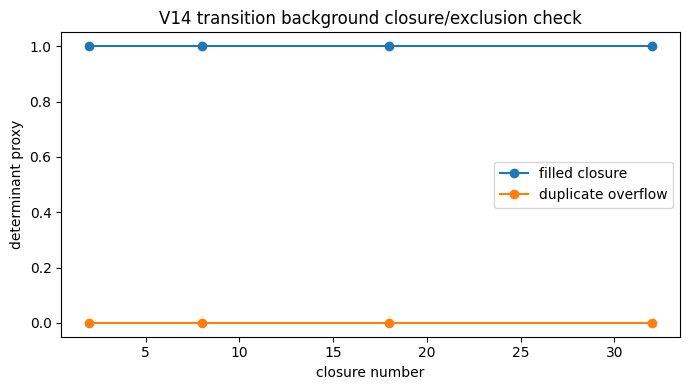

PosixPath('ecsm_electron_like_transition_rules_spectral_gaps_v14_out/fig_v14_transition_background_closure_determinants.png')

In [9]:
# CELL 9 — closure/exclusion background
def gram_det_for_mode_ids(ids): return 0.0 if len(ids)!=len(set(ids)) else 1.0
closure_numbers=[2,8,18,32]; rows=[]
for n in closure_numbers:
    ids=list(range(n)); rows.append({'closure_number':n,'filled_det':gram_det_for_mode_ids(ids),'overflow_duplicate_det':gram_det_for_mode_ids(ids+[ids[0]]),'allowed_closure':gram_det_for_mode_ids(ids)>0,'duplicate_forbidden':gram_det_for_mode_ids(ids+[ids[0]])==0})
closure_df=pd.DataFrame(rows); closure_df.to_csv(OUT/'transition_background_closure_determinants_v14.csv',index=False); display(closure_df)
duplicate_det=gram_det_for_mode_ids([0,0]); same_group_two_internal_det=gram_det_for_mode_ids([0,1]); all_mode_det=gram_det_for_mode_ids(list(range(32))); overflow_all_det=gram_det_for_mode_ids(list(range(32))+[0])
print('Duplicate determinant:',duplicate_det,'Same-group two-internal:',same_group_two_internal_det,'All-mode:',all_mode_det,'Overflow:',overflow_all_det)
plt.figure(figsize=(7,4)); plt.plot(closure_df.closure_number,closure_df.filled_det,marker='o',label='filled closure'); plt.plot(closure_df.closure_number,closure_df.overflow_duplicate_det,marker='o',label='duplicate overflow'); plt.xlabel('closure number'); plt.ylabel('determinant proxy'); plt.title('V14 transition background closure/exclusion check'); plt.legend(); savefig('fig_v14_transition_background_closure_determinants.png')

In [10]:
# CELL 10 — verdict
max_alpha_error=float(alpha_df.error.max()); q_error=abs(packet_summary['q_eff']+1.0)
iso_capacity=[2,6,10,14]; iso_closure=[2,8,18,32]
allowed_iso_count=len(allowed_iso); allowed_aniso_count=len(allowed_aniso)
forbidden_strength_max=float(trans_aniso.loc[~trans_aniso.allowed,'strength_proxy'].max())
iso_gap_width_max=float(iso_fam.gap_width.max()); aniso_gap_width_max=float(aniso_fam.gap_width.max())
eps_monotonic=bool(np.all(np.diff(eps_scan.max_transition_multiplet_width.values)>=-1e-12))
chi_allowed_preserved=bool((chi_df.n_allowed==chi_df.n_allowed.iloc[0]).all()); chi_families_preserved=bool((chi_df.n_transition_families==chi_df.n_transition_families.iloc[0]).all())
chi_gap_shift=float(chi_df.mean_allowed_gap.max()-chi_df.mean_allowed_gap.min())
def b(x): return 1.0 if bool(x) else 0.0
criteria=[
('packet remains q=-1 scaffold',q_error,q_error<1e-3),('packet N_plus near 0',abs(packet_summary['N_plus']),abs(packet_summary['N_plus'])<2e-3),('packet N_zero near 1',abs(packet_summary['N_zero']-1),abs(packet_summary['N_zero']-1)<2e-3),('packet N_minus near 3',abs(packet_summary['N_minus']-3),abs(packet_summary['N_minus']-3)<2e-3),('alpha/beta closure inherited',max_alpha_error,max_alpha_error<1e-12),
('V12/V13 bound shell energies inherited',len(base_radial),len(base_radial)==4),('isotropic modes generated',len(modes_iso),len(modes_iso)==32),('anisotropic modes generated',len(modes_aniso),len(modes_aniso)==32),('isotropic capacity ladder 2,6,10,14',b(base_radial.capacity.tolist()==iso_capacity),base_radial.capacity.tolist()==iso_capacity),('isotropic closure sequence 2,8,18,32',b(base_radial.closure.tolist()==iso_closure),base_radial.closure.tolist()==iso_closure),
('allowed transitions exist',allowed_iso_count,allowed_iso_count>0),('dipole-like rule preserves allowed count under anisotropy',abs(allowed_aniso_count-allowed_iso_count),allowed_aniso_count==allowed_iso_count),('forbidden transitions have zero strength',forbidden_strength_max,forbidden_strength_max==0.0),('isotropic transition families collapse to single gaps',iso_gap_width_max,iso_gap_width_max<1e-12),('anisotropy creates transition multiplet widths',aniso_gap_width_max,aniso_gap_width_max>0),('transition multiplet width grows with anisotropy',b(eps_monotonic),eps_monotonic),
('chi preserves allowed transition count',b(chi_allowed_preserved),chi_allowed_preserved),('chi preserves transition family count',b(chi_families_preserved),chi_families_preserved),('chi shifts mean transition gap',chi_gap_shift,chi_gap_shift>0),('duplicate occupancy collapses determinant',duplicate_det,duplicate_det==0.0),('same-group two-internal filling allowed',same_group_two_internal_det,same_group_two_internal_det==1.0),('all closure fillings allowed',b(closure_df.allowed_closure.all()),bool(closure_df.allowed_closure.all())),('all closure overflows by duplicate forbidden',b(closure_df.duplicate_forbidden.all()),bool(closure_df.duplicate_forbidden.all())),('all finite modes can be filled once',all_mode_det,all_mode_det==1.0),('all-mode overflow duplicate forbidden',overflow_all_det,overflow_all_det==0.0)]
verdict_df=pd.DataFrame(criteria,columns=['criterion','value','pass']); verdict_df.to_csv(OUT/'final_transition_rules_spectral_gaps_v14_verdict.csv',index=False); display(verdict_df)
n_pass=int(verdict_df['pass'].sum()); n_criteria=len(verdict_df)
final_label='PASS: ECSM bound shells generate structured transition rules and anisotropic spectral gaps' if n_pass==n_criteria else 'CONDITIONAL/FAIL: transition-rule criteria not all satisfied'
summary={'final_label':final_label,'n_pass':n_pass,'n_criteria':n_criteria,'q_eff':packet_summary['q_eff'],'n_modes':32,'n_allowed_transitions':allowed_iso_count,'transition_families':iso_fam.transition_family.tolist(),'isotropic_gap_width_max':iso_gap_width_max,'anisotropic_gap_width_max':aniso_gap_width_max,'chi_mean_gap_range':chi_gap_shift,'duplicate_det':duplicate_det,'same_group_two_internal_det':same_group_two_internal_det,'all_mode_det':all_mode_det,'overflow_all_det':overflow_all_det,'notes':'V14 is a transition-rule and spectral-gap bridge, not a full physical atomic spectroscopy derivation.'}
write_json(summary,'run_summary_v14.json')
print('Final label:',final_label); print(json.dumps(summary,indent=2))

,criterion,value,pass
0,packet remains q=-1 scaffold,0.000696,True
1,packet N_plus near 0,0.000972,True
2,packet N_zero near 1,0.000146,True
3,packet N_minus near 3,0.001118,True
4,alpha/beta closure inherited,0.000000,True
5,V12/V13 bound shell energies inherited,4.000000,True
6,isotropic modes generated,32.000000,True
7,anisotropic modes generated,32.000000,True
8,"isotropic capacity ladder 2,6,10,14",1.000000,True
9,"isotropic closure sequence 2,8,18,32",1.000000,True


Final label: PASS: ECSM bound shells generate structured transition rules and anisotropic spectral gaps
{
  "final_label": "PASS: ECSM bound shells generate structured transition rules and anisotropic spectral gaps",
  "n_pass": 25,
  "n_criteria": 25,
  "q_eff": -0.9993035720499918,
  "n_modes": 32,
  "n_allowed_transitions": 54,
  "transition_families": [
    "l0->l1",
    "l1->l2",
    "l2->l3"
  ],
  "isotropic_gap_width_max": 0.0,
  "anisotropic_gap_width_max": 0.08000000000000007,
  "chi_mean_gap_range": 0.11204734496828629,
  "duplicate_det": 0.0,
  "same_group_two_internal_det": 1.0,
  "all_mode_det": 1.0,
  "overflow_all_det": 0.0,
  "notes": "V14 is a transition-rule and spectral-gap bridge, not a full physical atomic spectroscopy derivation."
}


In [11]:
# CELL 11 — output manifest / zip
manifest=pd.DataFrame({'file':sorted([p.name for p in OUT.iterdir() if p.is_file()])}); manifest.to_csv(OUT/'output_file_manifest_v14.csv',index=False); display(manifest)
zip_path=Path(str(OUT)+'.zip')
with zipfile.ZipFile(zip_path,'w',compression=zipfile.ZIP_DEFLATED) as z:
    for p in OUT.iterdir():
        if p.is_file(): z.write(p,arcname=p.name)
print('Zipped output:',zip_path.resolve())

,file
0,alpha_beta_algebra_tests_v14.csv
1,anisotropic_bound_modes_v14.csv
2,anisotropic_transition_family_summary_v14.csv
3,anisotropic_transition_table_v14.csv
4,chi_deformed_transition_gap_scan_v14.csv
5,fig_v14_anisotropic_transition_gap_distributio...
6,fig_v14_anisotropic_transition_multiplet_width...
7,fig_v14_bound_modes_isotropic_vs_anisotropic.png
8,fig_v14_chi_transition_gap_shift.png
9,fig_v14_inherited_bound_energy_ladder.png


Zipped output: /content/ecsm_electron_like_transition_rules_spectral_gaps_v14_out.zip
